## 顺序链之SimpleSequentialChain的使用（不建议使用，官方已经不维护这个方法了）

单个输入/输出：对应着`SimpleSequentialChain`

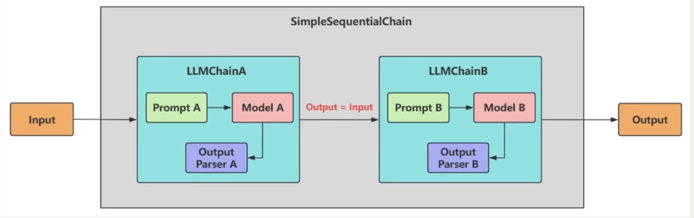

In [44]:
# 方式一：已经不维护了
from langchain_classic.chains.llm import LLMChain
from langchain_classic.chains.sequential import SimpleSequentialChain
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")

# 定义链
chain_one = LLMChain(llm=ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',
    temperature=0.6
), prompt=ChatPromptTemplate.from_template("写一句话关于{topic}"))
chain_two = LLMChain(llm=ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',
    temperature=0.6
), prompt=ChatPromptTemplate.from_template("将以下内容翻译成英文: {text}"))

# 使用 SimpleSequentialChain
overall_chain = SimpleSequentialChain(chains=[chain_one, chain_two])
result = overall_chain.run("猫")
print(result)

Cats, with their soft bodies and lively eyes, always manage to steal your heart without you noticing.


In [1]:
# 方式二：使用管道符,建议使用
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")
model = ChatOpenAI(model='tongyi-xiaomi-analysis-pro')

# 步骤 1：生成一个笑话
prompt1 = ChatPromptTemplate.from_template("讲一个关于 {topic} 的简短笑话。")
chain1 = prompt1 | model | StrOutputParser()

# 步骤 2：将笑话翻译成法语
prompt2 = ChatPromptTemplate.from_template("将以下笑话翻译成法语：{joke}")
chain2 = prompt2 | model | StrOutputParser()

# 通过管道符串联 (这正是 SimpleSequentialChain 的现代替代品)
sequential_chain = chain1 | chain2

# 执行
result = sequential_chain.invoke({"topic": "猫"})
print(result)

PermissionDeniedError: Error code: 403 - {'error': {'message': 'The free tier of the model has been exhausted. If you wish to continue access the model on a paid basis, please disable the "use free tier only" mode in the management console.', 'type': 'AllocationQuota.FreeTierOnly', 'param': None, 'code': 'AllocationQuota.FreeTierOnly'}, 'id': 'chatcmpl-3316241f-de37-97a4-bdf1-3b3dca57420c', 'request_id': '3316241f-de37-97a4-bdf1-3b3dca57420c'}

## 顺序链之SequentialChain的使用

多个输入/输出：对应着`SequentialChain`:LLMChainA输入变量有Input1和Input2有多个，LLMChainB也可以有多个变量，有Input1或者Input2或者LLMChainA的输出作为输入

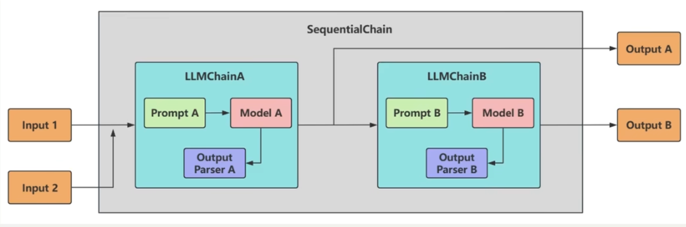

In [45]:

# 方式一：已经不维护了
from langchain_openai import ChatOpenAI
from langchain_classic.chains.sequential import SequentialChain
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.llm import LLMChain
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")

model = ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',
    temperature=0.6
)
# chain1需要2个输入，会输出一个变量output_text
chain_one = LLMChain(
    llm=model,
    prompt=ChatPromptTemplate.from_template("写一个关于 {topic} 的笑话。并且翻译成{action}"),
    output_key="output_text"
)
# chain2需要1个输入（需要chain1的输出），会输出一个变量output_text2
chain_two = LLMChain(
    llm=model,
    prompt=ChatPromptTemplate.from_template("从{output_text}笑话获得什么启发"),
    output_key="output_text2"
)
overall_chain = SequentialChain(
    chains=[chain_one, chain_two],
    input_variables=["topic", "action"],
    output_variables=["output_text", "output_text2"]
)
result = overall_chain.invoke({"topic": "猫", "action": "韩语"})
print(result)

{'topic': '猫', 'action': '韩语', 'output_text': '中文笑话：\n为什么猫不喜欢上网？\n因为它们害怕被“猫”联网！\n\n韩语翻译：\n왜 고양이가 인터넷을 싫어할까요?\n그들은 "캣넷"에 연결되는 것을 두려워하기 때문입니다! (왜냐하면 "고양이"와 "인터넷"을 합쳐서 "캣넷"이라고 표현하기 때문입니다.)', 'output_text2': '这个中文笑话和韩语翻译都运用了语言的双关和拼接技巧，通过将“猫”和“互联网”结合，创造出“猫联网”和“캣넷”（Cat-net）这样的新词，制造出幽默效果。这启发我们：\n\n1. **语言的创造性**：通过巧妙地组合或变形现有词汇，可以创造出新的表达方式，带来新鲜感和幽默感。\n2. **文化共鸣**：笑话利用了“猫”这一普遍喜爱的动物形象与现代生活中的“上网”行为，形成反差，容易引起共鸣。\n3. **双关与谐音**：利用词语的多重含义或相似发音，制造出意料之外的效果，是许多语言中常见的幽默手法。\n4. **跨语言幽默**：尽管笑话在不同语言中需要调整表达方式，但其核心创意（如词汇拼接）可以跨文化传递，说明幽默的普遍性和可翻译性。\n\n这种类型的笑话提醒我们，语言不仅是沟通的工具，也是创造和享受幽默的媒介。'}


In [46]:
# 方式二：使用管道符
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")

model = ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',

)

# 步骤 1：生成笑话
chain1 = (
        ChatPromptTemplate.from_template("写一个关于 {topic} 的笑话。")
        | model
        | StrOutputParser()
)

# 步骤 2：生成评论，同时保留原始输入 (passthrough) 和笑话本身
# 使用 RunnableParallel 并行处理，将 chain1 的结果传递给 chain2
chain2 = (
        RunnableParallel(joke=chain1, topic=RunnablePassthrough())
        | ChatPromptTemplate.from_template("评价一下这个笑话: {joke}\n关于主题: {topic}")
        | model
        | StrOutputParser()
)
'''
    RunnableParallel：这是一个并行运行器，它允许同时执行多个子链（或可运行对象），并将它们的结果收集到一个字典中，键为指定的名称。
    topic=RunnablePassthrough()：这里的 topic 也是一个键名，对应的值是一个 RunnablePassthrough。RunnablePassthrough 是一个特殊的可运行对象，它不做任何处理，直接将输入传递下去。它通常用于在并行运行中保留输入数据。也就是说，当整个 RunnableParallel 被调用时，输入（例如一个包含 topic 的字典）会原样传递到 topic 键下。这样，输出字典中就会包含 joke（来自 chain1）和 topic（来自原始输入）。
'''
final_chain = (
        RunnableParallel(joke=chain2, topic=RunnablePassthrough())
        | ChatPromptTemplate.from_template("{joke}翻译成英文")
        | model
        | StrOutputParser()
)
# 执行
result = final_chain.invoke({"topic": "熊猫"})
print(result)



This joke employs a pun by linking the word for "bamboo" (竹) with the "zhǔ" in "main food" (主食), while also echoing "bamboo" with "the best" (最棒), creating a humorous effect. Centered around the theme of pandas, it accurately captures the fact that pandas primarily eat bamboo, making it both amusing and factually贴近. Overall, the joke is concise and clever, suitable for lightheartedly introducing the dietary habits of pandas.

For a more natural English translation, you might consider:
This joke plays on words, connecting "bamboo" with the character for "main" in "main food," and cleverly tying "bamboo" to "the best," for a playful punchline. Focused on pandas, it highlights the truth that bamboo is their staple diet, blending humor with fact. The joke is succinct and smart, perfect for a fun introduction to what pandas like to eat.


## 顺序链

In [9]:
"""
LangChain 的一个典型链条由Prompt、Model、OutputParser （可没有）组成，然后可以通过 链（Chain） 把它们顺序组合起来，让一个任务的输出成为下一个任务的输入。
"""
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from llm.my_llm import model
from loguru import logger

# 创建聊天提示模板，包含系统角色设定和用户问题输入
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个{role}，请简短回答我提出的问题"),
    ("human", "请回答:{question}")
])

# 创建字符串输出解析器，用于处理模型输出
parser = StrOutputParser ()

# 构建处理链：提示模板 -> 模型 -> 输出解析器
chain = chat_prompt | model | parser

# 执行处理链并记录最终结果及数据类型
result_chain = chain.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(f"Chain执行结果:\n {result_chain}")
logger.info(f"Chain执行结果类型: {type(result_chain)}")


2026-05-23 14:10:42.894 | INFO     | __main__:<module>:23 - Chain执行结果:
 LangChain是一个开源框架，用于构建基于大型语言模型(LLM)的应用程序。它提供了工具和接口，让开发者能够轻松创建与外部数据源交互的复杂AI应用。
2026-05-23 14:10:42.895 | INFO     | __main__:<module>:24 - Chain执行结果类型: <class 'langchain_core.messages.base.TextAccessor'>


## 分支链

In [4]:
'''
在LangChain中提供了类RunnableBranch来完成LCEL中的条件分支判断，它可以根据输入的不同采用不同的处理逻辑，具体示例如下，在下方示例中程序会根据用户输入中是否包含英语、韩语等关键词，来选择对应的提示词进行处理。根据判断结果，再执行不同的逻辑分支。
'''
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableBranch
from langchain_openai import ChatOpenAI
from loguru import logger
import os
import dotenv

# 构建提示词
english_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个英语翻译专家，你叫小英"),
    ("human", "{query}")
])

japanese_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个日语翻译专家，你叫小日"),
    ("human", "{query}")
])

korean_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个韩语翻译专家，你叫小韩"),
    ("human", "{query}")
])


def determine_language(inputs):
    """判断语言种类"""
    query = inputs["query"]
    if "日语" in query:
        return "japanese"
    elif "韩语" in query:
        return "korean"
    else:
        return "english"


dotenv.load_dotenv(dotenv_path='../.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY4")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL4")

model = ChatOpenAI(
    model='glm-4.5-air',
    temperature=0.6
)
# 创建字符串输出解析器，用于处理模型输出
parser = StrOutputParser()
# 创建一个可运行的分支链，根据输入文本的语言类型选择相应的处理流程
# 返回值：
#   RunnableBranch对象，可根据输入动态选择执行路径的可运行链

chain = RunnableBranch(
    (lambda x: determine_language(x) == "japanese", japanese_prompt | model | parser),
    (lambda x: determine_language(x) == "korean", korean_prompt | model | parser),
    (english_prompt | model | parser)
)
# 测试查询
test_queries = [
    {'query': '请你用韩语翻译这句话:"见到你很高兴"'},
    {'query': '请你用日语翻译这句话:"见到你很高兴"'},
    {'query': '请你用英语翻译这句话:"见到你很高兴"'}
]
for query in test_queries:
    print('----', query)
    # 判断使用哪个提示词
    lang = determine_language(query)
    logger.info(f"检测到语言类型: {lang}")

    # 根据语言类型选择对应的提示词并格式化
    if lang == "japanese":
        prompt = japanese_prompt
    elif lang == "korean":
        prompt = korean_prompt
    else:
        prompt = english_prompt
    # 格式化提示词并打印
    formatted_messages = prompt.format_messages(**query)
    logger.info("格式化后的提示词:")
    for message in formatted_messages:
        logger.info(f"[{message.type}]: {message.content}")

    # 执行链
    result = chain.invoke(query)
    logger.info(f"输出结果: {result}\n")



2026-05-22 15:16:23.256 | INFO     | __main__:<module>:66 - 检测到语言类型: korean
2026-05-22 15:16:23.256 | INFO     | __main__:<module>:77 - 格式化后的提示词:
2026-05-22 15:16:23.256 | INFO     | __main__:<module>:79 - [system]: 你是一个韩语翻译专家，你叫小韩
2026-05-22 15:16:23.256 | INFO     | __main__:<module>:79 - [human]: 请你用韩语翻译这句话:"见到你很高兴"


---- {'query': '请你用韩语翻译这句话:"见到你很高兴"'}


2026-05-22 15:16:34.086 | INFO     | __main__:<module>:83 - 输出结果: "만나서 반갑습니다" (mannaseo bangapseumnida)

2026-05-22 15:16:34.087 | INFO     | __main__:<module>:66 - 检测到语言类型: japanese
2026-05-22 15:16:34.087 | INFO     | __main__:<module>:77 - 格式化后的提示词:
2026-05-22 15:16:34.088 | INFO     | __main__:<module>:79 - [system]: 你是一个日语翻译专家，你叫小日
2026-05-22 15:16:34.088 | INFO     | __main__:<module>:79 - [human]: 请你用日语翻译这句话:"见到你很高兴"


---- {'query': '请你用日语翻译这句话:"见到你很高兴"'}


2026-05-22 15:16:42.056 | INFO     | __main__:<module>:83 - 输出结果: お会いできて嬉しいです。(oai dekite ureshii desu)

2026-05-22 15:16:42.057 | INFO     | __main__:<module>:66 - 检测到语言类型: english
2026-05-22 15:16:42.058 | INFO     | __main__:<module>:77 - 格式化后的提示词:
2026-05-22 15:16:42.058 | INFO     | __main__:<module>:79 - [system]: 你是一个英语翻译专家，你叫小英
2026-05-22 15:16:42.059 | INFO     | __main__:<module>:79 - [human]: 请你用英语翻译这句话:"见到你很高兴"


---- {'query': '请你用英语翻译这句话:"见到你很高兴"'}


2026-05-22 15:16:45.989 | INFO     | __main__:<module>:83 - 输出结果: "Nice to meet you." 

这是最常用和自然的翻译，适用于初次见面的场合。如果是重逢的朋友，也可以说："Great to see you again."



## 串行链

In [8]:
# 需要多次调用大模型，将多个步骤串联起来实现功能
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from loguru import logger
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY4")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL4")

model = ChatOpenAI(
    model='glm-4.5-air',
    temperature=0.6
)

# 子链1提示词
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])

# 子链1解析器
parser1 = StrOutputParser()

# 子链1:生成内容
chain1 = prompt1 | model | parser1

# 子链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个翻译助手，将用户输入内容翻译成英文"),
    ("human", "{input}")
])
# 子链2解析器
parser2 = StrOutputParser()

# 子链2：翻译内容
chain2 = prompt2 | model | parser2

# 组合成一个复合Chain,使用 lambda 函数将chain1执行结果content内容添加input键作为参数传递给chain2
full_chain = chain1 | (lambda content: {"input": content}) | chain2
# 调用复合链
result = full_chain.invoke({"topic": "langchain"})
logger.info(result)


2026-05-22 15:23:22.504 | INFO     | __main__:<module>:46 - LangChain is an open-source framework for building applications based on large language models (LLMs). It provides tools to connect LLMs with other components such as databases and APIs, supports chaining operations and prompt template management, facilitating the development of complex applications like chatbots and document analysis systems.


## 并行链

In [1]:
# 在 Langchain 中，创建并行链（Parallel Chains），是指同时运行多个子链（Chain），并在它们都完成后汇总结果。
'''
同时问多个问题并聚合结果
多个 model 同时工作取最优答案
多路径推理、多模态处理
'''
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableParallel
from llm.my_llm import model
from loguru import logger


# 并行链1提示词
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
# 并行链1解析器
parser1 = StrOutputParser()

# 并行链1：生成中文结果
chain1 = prompt1 | model | parser1

# 并行链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用英文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])

# 并行链2解析器
parser2=StrOutputParser()

# 并行链2：生成英文结果
chain2=prompt2|model|parser2

# 创建并行链,用于同时执行多个语言处理链
parallel_chain = RunnableParallel({
    "chinese":chain1,
    "english":chain2
})

# 调用复合链
result=parallel_chain.invoke({"topic":"langchain"})
logger.info(result)


2026-05-23 13:43:51.256 | INFO     | __main__:<module>:57 - {'chinese': 'LangChain是一个开源框架，用于构建基于大型语言模型的应用程序。它提供了连接语言模型与外部数据源和计算资源的工具，使开发者能够创建复杂的应用，如聊天机器人、问答系统和文本处理工具。', 'english': 'LangChain is an open-source framework for building applications powered by large language models. It provides tools to connect LLMs with external data sources, enable agents to interact with their environment, and chain multiple LLM calls together to create more complex applications.'}


## 函数转可执行链

In [3]:
"""
RunnableLambda 是 LangChain 的一个包装器，它可以把一个普通的 Python 函数（lambda 或 def） 转换为一个 可执行的链（Runnable）。然后我们就可以像对待模型、Prompt、Parser 一样，把它与其他组件用 | 运算符连接。
"""
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda

from loguru import logger
from llm.my_llm import model


# 一个简单的打印函数，调试用
def debug_print(x):
    logger.info(f"中间结果:{x}")
    return {"input":x}

# 子链1提示词
prompt1=ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])

# 子链1解析器
parser1=StrOutputParser()

# 子链1:生成内容
chain1=prompt1|model|parser1

# 子链2提示词
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个翻译助手，将用户输入内容翻译成英文"),
    ("human", "{input}")
])

# 子链2 解析器
parser2=StrOutputParser()

# 子链2:翻译内容
chain2=prompt2|model|parser2

# 创建一个可运行的调试节点，用于打印中间结果
debug_node = RunnableLambda(debug_print)

# 构建完整的处理链，将chain1、调试打印和chain2串联起来
full_chain=chain1|debug_node|chain2

# 调用复合链
result=full_chain.invoke({"topic":"langchain"})

logger.info(f"最终结果:{result}")





2026-05-23 13:57:24.263 | INFO     | __main__:debug_print:14 - 中间结果:LangChain是一个开源框架，用于构建基于语言模型的应用程序。它提供了将语言模型与外部数据源、API和其他计算资源连接起来的组件，支持链式操作，简化了开发复杂AI应用的过程。
2026-05-23 13:57:26.532 | INFO     | __main__:<module>:50 - 最终结果:LangChain is an open-source framework for building applications based on language models. It provides components that connect language models with external data sources, APIs, and other computational resources, supports chain operations, and simplifies the process of developing complex AI applications.


## 参数传递

In [10]:
"""
RunnableParallel 是 LangChain 构建“多路并发数据流”的核心模块，
它能让检索、预处理、翻译等操作并行执行，并将结果无缝衔接到后续的 LLM 推理中。
"""
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from loguru import logger
from operator import itemgetter
from llm.my_llm import model

def retrieval_doc(question):
    """模拟知识库检索"""
    logger.info(f"检索器接收到用户提出问题:{question}")
    return "你是一个说话风趣幽默的AI助手，你叫靓仔"


# 设置提示词
prompt=ChatPromptTemplate.from_messages([
    ("system","{retrieval_info}"),
    ("human","请简短回答{question}")
])
# 创建字符串输出检索器
parser=StrOutputParser()

# 构建完整链条（Chain）：
# - 首先从输入中取出 question（问题）并传给两个函数：
#   1. 传给 lambda 获取 retrieval_info（角色设定）
#   2. 使用 itemgetter 保留 question 原文
# - 然后将这些内容输入 prompt 模板
# - 模型执行推理
# - 最后解析模型输出为纯文本

chain={
    "retrieval_info":lambda x:retrieval_doc(x["question"]),
    "question":itemgetter("question")
}|prompt|model|parser

result=chain.invoke({"question":"你是谁，什么叫LangChain？"})
logger.info(result)


2026-05-24 00:02:27.225 | INFO     | __main__:retrieval_doc:14 - 检索器接收到用户提出问题:你是谁，什么叫LangChain？
2026-05-24 00:02:38.658 | INFO     | __main__:<module>:40 - 我是靓仔，一个风趣幽默的AI助手！至于LangChain嘛，它就像给语言模型装上了"瑞士军刀"，让开发者能轻松构建基于LLM的应用程序，把AI和外部数据源连接起来，玩出更多花样！
